## Thelia的手撕线性回归尝试！

### 随机生成一个数据集吧~

In [ ]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import time

n_samples = 60
seed = int(time.time())  # 每秒钟更新一次随机种子，确保每次运行生成不同的样本
# 原函数参数 y = a * x + b
random.seed(seed)
a = random.uniform(-4, 4)
b = random.uniform(-10, 10)

# 方差与样本数（方差越大，点越分散）
noise_std = random.uniform(5, 10) * abs(a)
rng = np.random.default_rng(seed)
x = np.arange(1, n_samples + 1)
noise = rng.normal(0, noise_std, size=n_samples)
y = a * x + b + noise

df = pd.DataFrame({
    'x': x,
    'y': np.round(y, 1),
})

csv_path = Path('linear_regression_sample.csv')
df.to_csv(csv_path, index=False)
print(f'已生成 {n_samples} 条样本，保存到: {csv_path.resolve()}')
df.head()

已生成 60 条样本，保存到: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/linear_regression_sample.csv


,x,y
0,1,-2.2
1,2,-2.2
2,3,-3.2
3,4,-2.2
4,5,-1.0


### 导入包

In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 导入数据

In [243]:
dataset = pd.read_csv('linear_regression_sample.csv')
print(dataset)
X = dataset.iloc[:, :-1].values #输入矩阵
y = dataset.iloc[:, -1].values #输出矩阵

     x    y
0    1 -2.2
1    2 -2.2
2    3 -3.2
3    4 -2.2
4    5 -1.0
5    6 -0.8
6    7 -0.9
7    8 -2.0
8    9  0.9
9   10 -0.5
10  11 -2.2
11  12 -0.4
12  13 -1.7
13  14 -1.8
14  15  0.2
15  16  1.4
16  17  0.8
17  18 -1.2
18  19  0.9
19  20  1.5
20  21  1.4
21  22  0.5
22  23  2.1
23  24  1.8
24  25  2.6
25  26  2.5
26  27  1.1
27  28  2.5
28  29  1.8
29  30  1.7
30  31  3.5
31  32  2.0
32  33  1.5
33  34  2.6
34  35  3.7
35  36  2.7
36  37  5.4
37  38  4.0
38  39  3.1
39  40  4.0
40  41  3.6
41  42  6.5
42  43  5.8
43  44  4.0
44  45  5.1
45  46  5.5
46  47  4.9
47  48  5.5
48  49  4.0
49  50  5.8
50  51  5.9
51  52  6.4
52  53  6.4
53  54  6.7
54  55  7.7
55  56  5.2
56  57  6.1
57  58  6.5
58  59  8.3
59  60  9.0


#### 试着画个散点图？

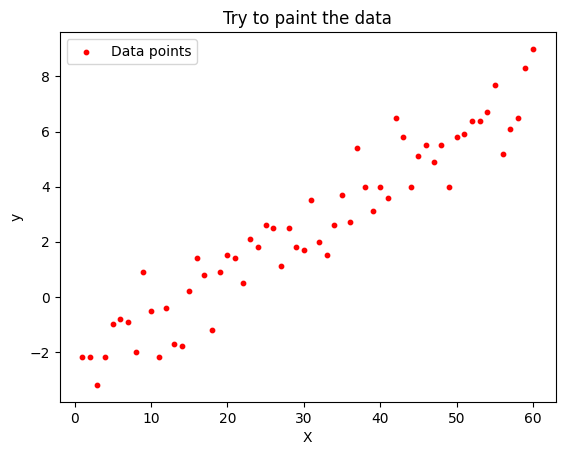

In [244]:
plt.scatter(X, y, color='red', s=10, label='Data points')
plt.title('Try to paint the data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### 划分一下训练数据和测试数据~

In [245]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

### 线性回归，启动！

In [246]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, n_iters=30000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape #数据量&特征数
        # 初始化权重和偏置
        self.w = np.zeros(n_features)
        self.b = 0

        # 梯度下降
        for _ in range(self.n_iters):
            y_predicted = np.dot(X, self.w) + self.b
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.w) + self.b
        return linear_model
        

### 训练一下

In [247]:
LM = LinearRegression()
LM.fit(X_train, y_train)

### 看看结果

Learned parameters: w=0.1608, b=-2.3349
True parameters: w=0.1671, b=-2.5751
Test MSE: 0.9787
Preset Variance: 1.0022


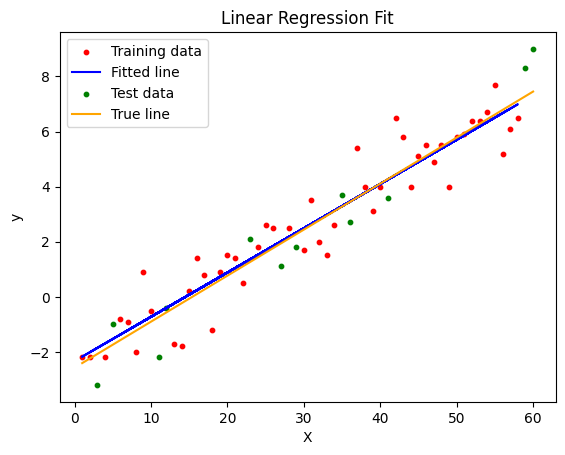

In [248]:
plt.scatter(X_train, y_train, color='red', s=10, label='Training data')
plt.plot(X_train, LM.predict(X_train), color='blue', label='Fitted line')
plt.scatter(X_test, y_test, color='green', s=10, label='Test data')
plt.plot(X, a * X + b, color='orange', label='True line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(['Training data','Fitted line','Test data','True line'])
print(f'Learned parameters: w={LM.w[0]:.4f}, b={LM.b:.4f}')
print(f'True parameters: w={a:.4f}, b={b:.4f}')
print(f'Test MSE: {np.mean((LM.predict(X_test) - y_test) ** 2):.4f}')
print(f'Preset Variance: {noise_std**2:.4f}')